<a href="https://colab.research.google.com/github/Halgratir/Gacha-Games/blob/main/Gacha_Games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import CSV

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

Load Data

In [77]:
gacha_df = pd.read_excel('/content/Gacha_Games .xlsx')
gacha_df.head(10)

,Game_Title,Art_Style,Gacha_Type,Status,Monthly_F2P_Pull_Income,Currency_Cost_Per_Pull_USD,Banner_Duration,Platform,Region,Probability_Highest_Rate,Hard_Pity,Hard_Pity_Count,Soft_Pity,Monthly_Downloads,Lifetime_Downloads,Highest_Revenue_Monthly,Lowest_Revenue_Monthly,Age_Rating,Developers
0,100 Sleeping Princes and the Kingdom of Dreams,Anime 2D,Characters,Active,50,2.50,14,"Android, iOS","Japan, China, Taiwan, Korea",0.0350,Yes,No,No,15000.0,12000000.0,5000000,120000,12,GCREST Inc.
1,2.5 Dimensional Seduction: Angels on Stage,Anime 3D,Characters,Service Ending,50,2.20,14,"Android, iOS, PC",Japan,0.0300,Yes,200,Yes,250000.0,2000000.0,2000000,20000,17,Team CARAVAN
2,Compass,Anime 3D,Characters,Active,50,2.00,14,"Android, iOS",Japan,0.0100,No,No,No,20000.0,15000000.0,3000000,800000,12,NHN PlayArt Co. Ltd.
3,ABYSSDIA,Anime 2D,"Characters, Artifacts",Active,50,2.25,14,"Android, iOS, PC","Japan, Global",0.0300,Yes,No,No,30000.0,5000000.0,40000,5000,12,"Ring Games Co,. Ltd"
4,Action Tamarin,Anime 3D,"Characters, Supporters",Active,50,2.25,14,"Android, iOS, PC, Nintendo Switch","Japan, Global",0.0300,Yes,100,No,25000.0,3000000.0,800000,120000,17,Gremory Games
5,Aether Gazer,Anime 3D,"Characters, Modifiers",Active,70,2.00,21,"Android, iOS, PC","China, Global",0.0160,Yes,140,Yes,80000.0,5000000.0,2100000,274000,12,Yongshi
6,AFK Arena,Stylized 2D,Heroes,Active,80,2.50,14,"Android, iOS",Global,0.0461,Yes,No,No,40000.0,50000000.0,105400000,2000000,12,Lilith Games
7,AFK Journey,Stylized 3D,Heroes,Active,65,2.25,21,"Android, iOS, PC",Global,0.0205,Yes,40,Yes,1200000.0,18000000.0,71800000,2590000,12,Lilith Games
8,Age of Ishtaria,Anime 2D,Cards,Active,50,2.25,14,"Android, iOS, PC","Japan, North America",0.0200,No,No,No,5000.0,5000000.0,1000000,30000,12,Silicon Studio
9,Alchemy Stars,Anime 2D,Characters,Closed,55,2.30,14,"Android, iOS, PC","Global, China",0.0200,Yes,270,No,50000.0,15000000.0,8000000,150000,12,Tourdog Studio


Success! It reads

If the preview does not load on my github repo. Here is the link to view it: https://nbviewer.org/

Transformation

In [78]:
gacha_df['Hard_Pity_Count'] = pd.to_numeric(gacha_df['Hard_Pity_Count'].replace('No', 0))

/tmp/ipykernel_29060/1546531571.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gacha_df['Hard_Pity_Count'] = pd.to_numeric(gacha_df['Hard_Pity_Count'].replace('No', 0))


Creating a new feature: Total cost to reach pity

In [79]:
gacha_df['Pity_Cost'] = gacha_df['Hard_Pity_Count'] * gacha_df['Currency_Cost_Per_Pull_USD']

**PYTHON FUNCTION**

In [80]:
def classify_pity_tier(count):
  #Categorizes the fairness of the pity system
  if count == 0: return "No Guarantee"
  if count <= 90: return "Friendly"
  if count <= 100: return "Standard"
  return "Expensive"
  gacha_df['Pity_Tier'] = gacha_df['Hard_Pity_Count'].apply(classify_pity_tier)

**PYTHON CLASS & OBJECTS**

In [81]:
class GachaMarket:
    def __init__(self, data):
        self.data = data

    def summary(self):
        top_game = self.data.loc[self.data['Highest_Revenue_Monthly'].idxmax()]
        return f"Top Game: {top_game['Game_Title']} (${top_game['Highest_Revenue_Monthly']:,})"

analysis_obj = GachaMarket(gacha_df)
print(analysis_obj.summary())

Top Game: Fate Grand Order ($200,000,000)


Statistical Analysis

**Question** Which art style generates the most revenue on average?

In [82]:
art_stats = gacha_df.groupby('Art_Style')['Highest_Revenue_Monthly'].mean().sort_values(ascending=False)
print("\n--- Average Revenue by Art Style ---")
print(art_stats)


--- Average Revenue by Art Style ---
Art_Style
Cartoon 3D         3.740000e+07
Comic 3D           2.450000e+07
Anime 3D           2.430212e+07
Realistic 3D       1.998889e+07
Stylized 2D        1.703750e+07
Watercolor 2D      1.500000e+07
Stylized 3D        1.480250e+07
Pixel Art          8.258333e+06
Anime 2D           7.450011e+06
Cartoon 2D         5.833333e+06
Dark Fantasy 2D    4.000000e+06
HD-2D              1.500000e+06
Name: Highest_Revenue_Monthly, dtype: float64


**SUPPORTING GRAPH**

/tmp/ipykernel_29060/2666886198.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=art_stats.index, y=art_stats.values, palette='viridis')


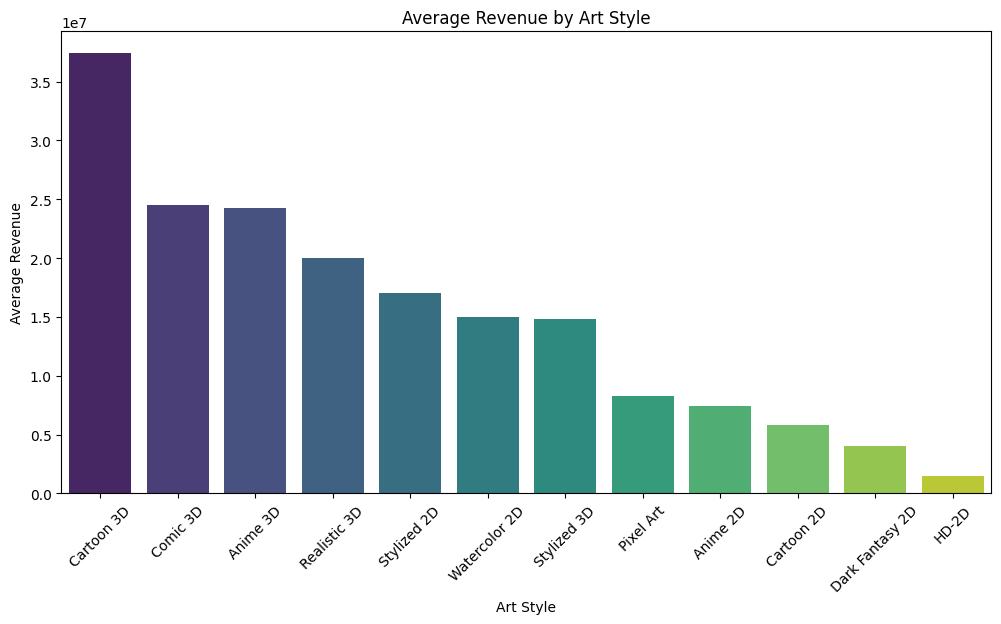

In [83]:
plt.figure(figsize=(12,6))
sns.barplot(x=art_stats.index, y=art_stats.values, palette='viridis')
plt.title('Average Revenue by Art Style')
plt.xlabel('Art Style')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()

**LINEAR REGRESSION**

**QUESTION** Does more downloads equal more revenue?

**Add Graph**

In [84]:
import matplotlib
import seaborn as sns
from sklearn.linear_model import LinearRegression

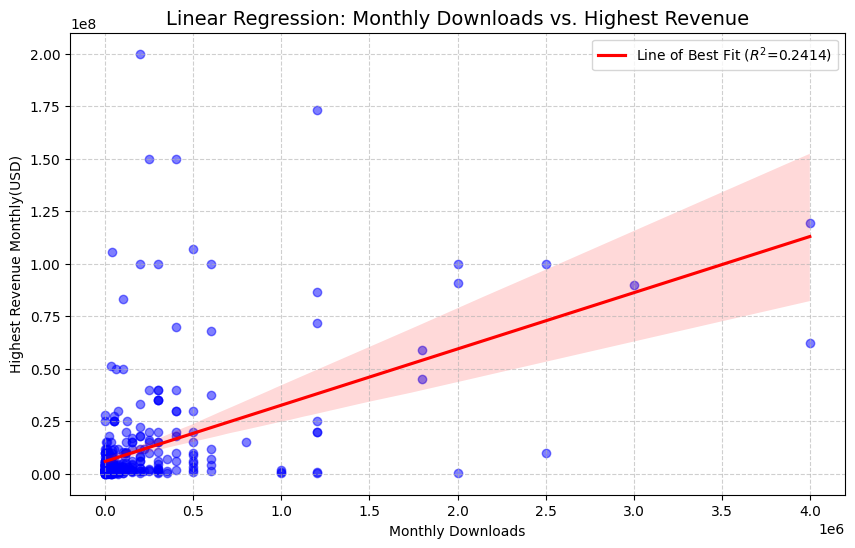

In [85]:
#Prepare the data
X = gacha_df[['Monthly_Downloads']].fillna(0)
y = gacha_df['Highest_Revenue_Monthly']
#run the model
model = LinearRegression().fit(X, y)
r_squared = model.score(X,y)
#create the visualization
plt.figure(figsize = (10,6))
sns.regplot(x='Monthly_Downloads', y='Highest_Revenue_Monthly', data=gacha_df,
            scatter_kws={'alpha':0.5, 'color': 'blue'},
            line_kws={'color':'red', 'label': f'Line of Best Fit ($R^2$={r_squared:.4f})'})
plt.title('Linear Regression: Monthly Downloads vs. Highest Revenue', fontsize=14)
plt.xlabel('Monthly Downloads')
plt.ylabel('Highest Revenue Monthly(USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()